In [1]:
import os
from pathlib import Path
from typing import Dict, Optional, Tuple
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk
import data_loader as dl


In [2]:
from pathlib import Path


def get_project_root() -> Path:
    cwd = Path.cwd().resolve()
    return cwd.parent if cwd.name == "scripts" else cwd


base_dir = get_project_root()
data_intermediate_dir = base_dir / "data_intermediate"
data_intermediate_dir.mkdir(parents=True, exist_ok=True)
df_neon = dl.df_neon.copy()


In [3]:
trend_file = data_intermediate_dir / "mk_two_PRCP_TMAX_TMIN_AI.csv"
if not trend_file.exists():
    raise FileNotFoundError(f"Required trend file not found: {trend_file}")
df_trend = pd.read_csv(trend_file)


In [4]:
df_trend_recent = df_trend[(df_trend["n"]==30)]

In [5]:
df_spei = pd.read_csv(base_dir / "data_intermediate_spei_monthly" / "mk_two_spei_monthly.csv")


In [6]:
df_spei_recent = df_spei[df_spei["window_type"]=="recent_30yr"]

In [7]:
shp_path = str(base_dir / "US_CONUS_Neon_shapefile" / "US_Neon.shp")


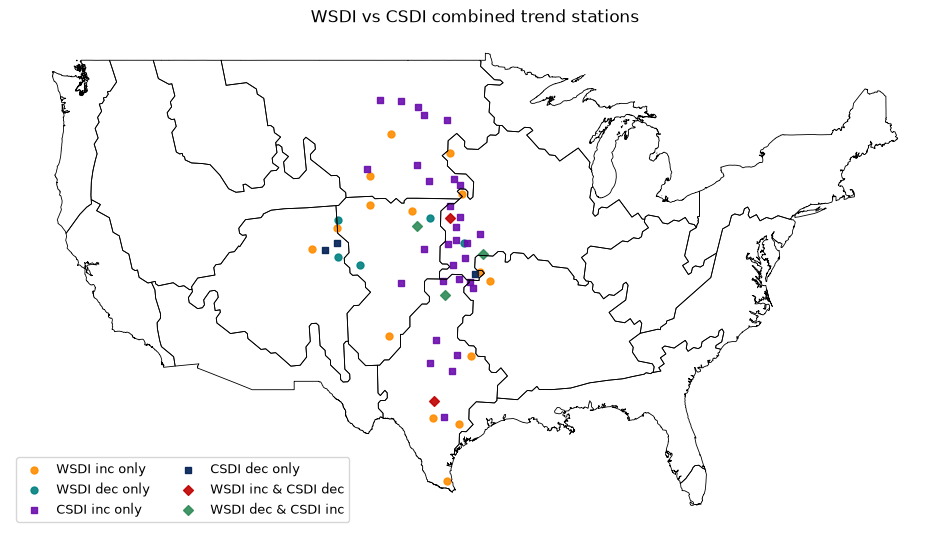

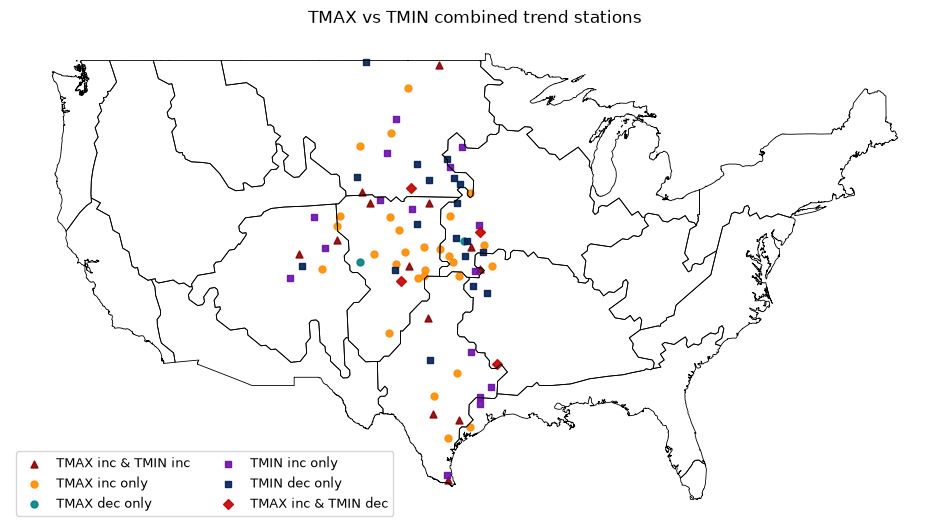

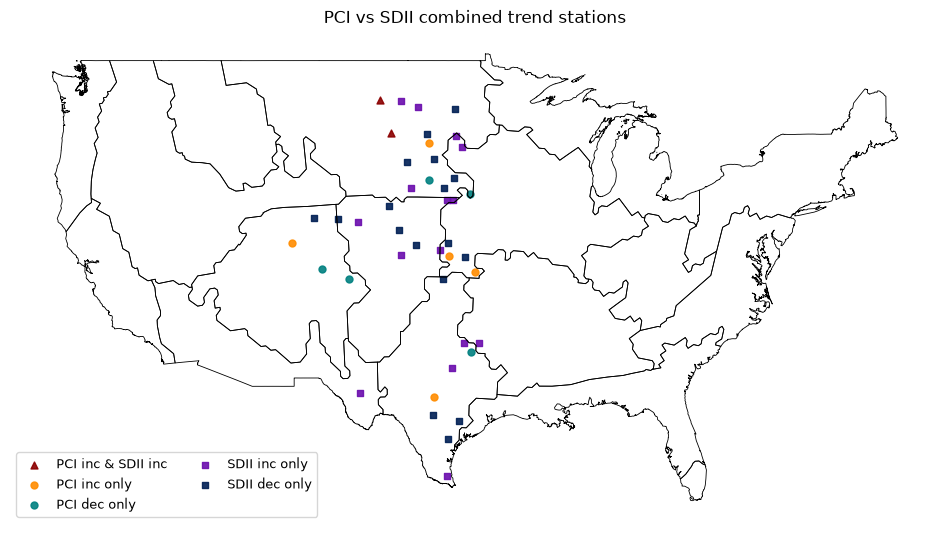

In [8]:


def plot_two_variable_trend_combos_on_shapefile(
    df_stations: pd.DataFrame,
    df_trends: pd.DataFrame,
    shp_path: str,
    var1: str = "WSDI",
    var2: str = "CSDI",
    station_id_col: str = "ID",
    lat_col: str = "Lat",
    lon_col: str = "Lon",
    variable_col: str = "variable",
    trend_col: str = "trend",
    increasing_label: str = "increasing",
    decreasing_label: str = "decreasing",
    no_trend_label: str = "no trend",
    station_crs: str = "EPSG:4326",
    figsize: tuple = (12, 8),
    boundary_color: str = "black",
    boundary_lw: float = 0.6,
    point_size: float = 25,
    alpha: float = 0.9,
    title: str | None = None,
    colors: dict | None = None,
    save_dir: str | None = None,
    filename: str | None = None,
    dpi: int = 300,
    show_mixed: bool = True,
):
    """
    Plot station markers based on combined trend classes of two variables (var1, var2).

    Categories shown (if present):
      - both_inc, both_dec
      - var1_only_inc, var1_only_dec
      - var2_only_inc, var2_only_dec
      - mixed_inc_dec (var1 inc, var2 dec), mixed_dec_inc (var1 dec, var2 inc) if show_mixed=True

    Notes
    -----
    Uses station_id_col to merge. Stations without both var1 and var2 trend rows will be dropped.
    """

    # ---- checks ----
    for col in [station_id_col, lat_col, lon_col]:
        if col not in df_stations.columns:
            raise ValueError(f"df_stations missing column: {col}")
    for col in [station_id_col, variable_col, trend_col]:
        if col not in df_trends.columns:
            raise ValueError(f"df_trends missing column: {col}")

    # ---- default colors (override via `colors`) ----
    default_colors = {
        "both_inc": "#8B0000",        # dark red
        "both_dec": "#0B3D91",        # deep blue
        "var1_only_inc": "#FF8C00",   # orange
        "var1_only_dec": "#008080",   # teal
        "var2_only_inc": "#6A0DAD",   # purple
        "var2_only_dec": "#001F54",   # navy
        "mixed_inc_dec": "#C00000",   # red (var1 inc, var2 dec)  (your preference)
        "mixed_dec_inc": "#2E8B57",   # green (var1 dec, var2 inc)
    }
    if colors is not None:
        default_colors.update(colors)

    # ---- shapefile ----
    gdf_shape = gpd.read_file(shp_path)
    if gdf_shape.crs is None:
        raise ValueError("Shapefile has no CRS defined. Define it in GIS or set it in code.")

    # ---- make trends table for var1 and var2 (ID -> trend) ----
    t = df_trends[[station_id_col, variable_col, trend_col]].copy()
    t[variable_col] = t[variable_col].astype(str).str.strip()
    t[trend_col] = t[trend_col].astype(str).str.strip().str.lower()

    t1 = t[t[variable_col] == var1][[station_id_col, trend_col]].rename(columns={trend_col: f"{var1}_trend"})
    t2 = t[t[variable_col] == var2][[station_id_col, trend_col]].rename(columns={trend_col: f"{var2}_trend"})

    # if duplicates exist per ID-variable, keep first (or you can change to something else)
    t1 = t1.drop_duplicates(subset=[station_id_col], keep="first")
    t2 = t2.drop_duplicates(subset=[station_id_col], keep="first")

    # ---- merge station coords + both trend columns ----
    s = df_stations[[station_id_col, lat_col, lon_col]].copy()
    m = s.merge(t1, on=station_id_col, how="inner").merge(t2, on=station_id_col, how="inner")

    # normalize expected labels
    inc_lab = increasing_label.lower()
    dec_lab = decreasing_label.lower()
    nt_lab = no_trend_label.lower()

    v1 = f"{var1}_trend"
    v2 = f"{var2}_trend"

    def is_inc(x): return x == inc_lab
    def is_dec(x): return x == dec_lab
    def is_nt(x):  return x == nt_lab

    # ---- define category masks ----
    masks = {
        "both_inc": (m[v1].apply(is_inc) & m[v2].apply(is_inc)),
        "both_dec": (m[v1].apply(is_dec) & m[v2].apply(is_dec)),
        "var1_only_inc": (m[v1].apply(is_inc) & m[v2].apply(is_nt)),
        "var1_only_dec": (m[v1].apply(is_dec) & m[v2].apply(is_nt)),
        "var2_only_inc": (m[v1].apply(is_nt) & m[v2].apply(is_inc)),
        "var2_only_dec": (m[v1].apply(is_nt) & m[v2].apply(is_dec)),
        "mixed_inc_dec": (m[v1].apply(is_inc) & m[v2].apply(is_dec)),
        "mixed_dec_inc": (m[v1].apply(is_dec) & m[v2].apply(is_inc)),
    }

    # ---- build GeoDataFrames per category ----
    def to_gdf(df_sub: pd.DataFrame) -> gpd.GeoDataFrame:
        gdf = gpd.GeoDataFrame(
            df_sub,
            geometry=gpd.points_from_xy(df_sub[lon_col], df_sub[lat_col]),
            crs=station_crs,
        )
        return gdf.to_crs(gdf_shape.crs)

    gdfs = {k: to_gdf(m.loc[mask].copy()) for k, mask in masks.items()}

    # ---- plot ----
    fig, ax = plt.subplots(figsize=figsize)
    gdf_shape.boundary.plot(ax=ax, color=boundary_color, linewidth=boundary_lw)

    def plot_cat(cat, marker, label):
        gdf_cat = gdfs[cat]
        if gdf_cat.empty:
            return
        gdf_cat.plot(
            ax=ax,
            marker=marker,
            color=default_colors[cat],
            markersize=point_size,
            alpha=alpha,
            label=label,
        )

    # main combos
    plot_cat("both_inc", "^", f"{var1} inc & {var2} inc")
    plot_cat("both_dec", "v", f"{var1} dec & {var2} dec")

    # single-variable only (keep them as circles so triangles stay meaningful)
    plot_cat("var1_only_inc", "o", f"{var1} inc only")
    plot_cat("var1_only_dec", "o", f"{var1} dec only")
    plot_cat("var2_only_inc", "s", f"{var2} inc only")
    plot_cat("var2_only_dec", "s", f"{var2} dec only")

    # mixed
    if show_mixed:
        plot_cat("mixed_inc_dec", "D", f"{var1} inc & {var2} dec")
        plot_cat("mixed_dec_inc", "D", f"{var1} dec & {var2} inc")

    ax.set_axis_off()

    if title is None:
        title = f"Combined trend stations: {var1} vs {var2}"
    ax.set_title(title)

    ax.legend(loc="lower left", frameon=True, fontsize=9, ncol= 2)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        if filename is None:
            filename = f"{var1}_{var2}_combined_trends.jpeg"
        outpath = os.path.join(save_dir, filename)
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight")

    return fig, ax, gdfs, m
fig, ax, gdfs, merged = plot_two_variable_trend_combos_on_shapefile(
    df_stations=df_neon,
    df_trends=df_trend_recent,
    shp_path=shp_path,
    var1="WSDI",
    var2="CSDI",
    save_dir=str(base_dir / "Figures_trend") + "/",
    title="WSDI vs CSDI combined trend stations",
)
# TMAX vs TMIN
fig, ax, gdfs, merged = plot_two_variable_trend_combos_on_shapefile(
    df_stations=df_neon,
    df_trends=df_trend_recent,
    shp_path=shp_path,
    var1="TMAX",
    var2="TMIN",
    save_dir=str(base_dir / "Figures_trend") + "/",
    title="TMAX vs TMIN combined trend stations",
    # optional: give a specific filename
    filename="TMAX_TMIN_combined_trends.jpeg",
)

custom_colors_pci_sdii = {
    "both_inc": "#8B0000",        # PCI inc & SDII inc
    "both_dec": "#0B3D91",        # PCI dec & SDII dec
    "var1_only_inc": "#FF8C00",   # PCI inc only
    "var1_only_dec": "#008080",   # PCI dec only
    "var2_only_inc": "#6A0DAD",   # SDII inc only
    "var2_only_dec": "#001F54",   # SDII dec only
    "mixed_inc_dec": "#8B4513",   # PCI inc & SDII dec
    "mixed_dec_inc": "#C71585",   # PCI dec & SDII inc
}

fig, ax, gdfs, merged = plot_two_variable_trend_combos_on_shapefile(
    df_stations=df_neon,
    df_trends=df_trend_recent,
    shp_path=shp_path,
    var1="PCI",
    var2="SDII",
    colors=custom_colors_pci_sdii,
    save_dir=str(base_dir / "Figures_trend") + "/",
    title="PCI vs SDII combined trend stations",
    filename="PCI_SDII_combined_trends.jpeg",
)



In [9]:


def plot_three_variable_scenarios_on_shapefile(
    df_stations: pd.DataFrame,
    df_trends: pd.DataFrame,
    shp_path: str,
    var_tmax: str = "TMAX",
    var_tmin: str = "TMIN",
    var_prcp: str = "PRCP",
    station_id_col: str = "ID",
    lat_col: str = "Lat",
    lon_col: str = "Lon",
    variable_col: str = "variable",
    trend_col: str = "trend",
    increasing_label: str = "increasing",
    decreasing_label: str = "decreasing",
    no_trend_label: str = "no trend",
    station_crs: str = "EPSG:4326",
    figsize: tuple = (12, 8),
    boundary_color: str = "black",
    boundary_lw: float = 0.6,
    point_size: float = 60,
    alpha: float = 0.9,
    title: str | None = None,
    colors: dict | None = None,
    markers: dict | None = None,
    save_dir: str | None = None,
    filename: str | None = None,
    dpi: int = 300,
):
    """
    Plot specific 3-variable trend scenarios:
      A) TMAX inc & TMIN inc & PRCP not inc (PRCP is dec or no trend)
      B) TMAX inc & TMIN inc & PRCP inc
      C) TMAX dec & TMIN dec & PRCP dec
    """

    # checks
    for col in [station_id_col, lat_col, lon_col]:
        if col not in df_stations.columns:
            raise ValueError(f"df_stations missing column: {col}")
    for col in [station_id_col, variable_col, trend_col]:
        if col not in df_trends.columns:
            raise ValueError(f"df_trends missing column: {col}")

    # defaults you can override
    default_colors = {
        "warm_not_wet": "#E69F00",  # orange
        "warm_and_wet": "#D55E00",  # red-orange
        "cool_and_dry": "#0072B2",  # blue
    }
    default_markers = {
        "warm_not_wet": "^",  # upright triangle
        "warm_and_wet": "o",  # circle
        "cool_and_dry": "v",  # downward triangle
    }
    if colors:
        default_colors.update(colors)
    if markers:
        default_markers.update(markers)

    # shapefile
    gdf_shape = gpd.read_file(shp_path)
    if gdf_shape.crs is None:
        raise ValueError("Shapefile has no CRS defined. Define it in GIS or set it in code.")

    # prepare trends
    t = df_trends[[station_id_col, variable_col, trend_col]].copy()
    t[variable_col] = t[variable_col].astype(str).str.strip()
    t[trend_col] = t[trend_col].astype(str).str.strip().str.lower()

    inc = increasing_label.lower()
    dec = decreasing_label.lower()
    nt = no_trend_label.lower()

    def get_var_trend(varname: str) -> pd.DataFrame:
        out = t[t[variable_col] == varname][[station_id_col, trend_col]].copy()
        out = out.drop_duplicates(subset=[station_id_col], keep="first")
        out = out.rename(columns={trend_col: f"{varname}_trend"})
        return out

    tmax = get_var_trend(var_tmax)
    tmin = get_var_trend(var_tmin)
    prcp = get_var_trend(var_prcp)

    s = df_stations[[station_id_col, lat_col, lon_col]].copy()
    m = s.merge(tmax, on=station_id_col, how="inner") \
         .merge(tmin, on=station_id_col, how="inner") \
         .merge(prcp, on=station_id_col, how="inner")

    TMAXc = f"{var_tmax}_trend"
    TMINc = f"{var_tmin}_trend"
    PRCPc = f"{var_prcp}_trend"

    # scenarios
    mask_warm_not_wet = (m[TMAXc] == inc) & (m[TMINc] == inc) & (m[PRCPc] != inc)
    mask_warm_and_wet = (m[TMAXc] == inc) & (m[TMINc] == inc) & (m[PRCPc] == inc)
    mask_cool_and_dry = (m[TMAXc] == dec) & (m[TMINc] == dec) & (m[PRCPc] == dec)

    scenarios = {
        "warm_not_wet": (mask_warm_not_wet, f"{var_tmax} inc & {var_tmin} inc; {var_prcp} not inc"),
        "warm_and_wet": (mask_warm_and_wet, f"{var_tmax} inc & {var_tmin} inc & {var_prcp} inc"),
        "cool_and_dry": (mask_cool_and_dry, f"{var_tmax} dec & {var_tmin} dec & {var_prcp} dec"),
    }

    def to_gdf(df_sub: pd.DataFrame) -> gpd.GeoDataFrame:
        gdf = gpd.GeoDataFrame(
            df_sub,
            geometry=gpd.points_from_xy(df_sub[lon_col], df_sub[lat_col]),
            crs=station_crs,
        )
        return gdf.to_crs(gdf_shape.crs)

    gdfs = {}
    for key, (mask, _) in scenarios.items():
        gdfs[key] = to_gdf(m.loc[mask].copy())

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    gdf_shape.boundary.plot(ax=ax, color=boundary_color, linewidth=boundary_lw)

    for key, (_, label) in scenarios.items():
        gdf_cat = gdfs[key]
        if gdf_cat.empty:
            continue
        gdf_cat.plot(
            ax=ax,
            marker=default_markers[key],
            color=default_colors[key],
            markersize=point_size,
            alpha=alpha,
            label=f"{label} (n={len(gdf_cat)})",
        )

    ax.set_axis_off()
    if title is None:
        title = f"3-variable scenarios: {var_tmax}, {var_tmin}, {var_prcp}"
    ax.set_title(title)
    ax.legend(loc="lower left", frameon=True, fontsize=9)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        if filename is None:
            filename = f"{var_tmax}_{var_tmin}_{var_prcp}_scenarios.jpeg"
        outpath = os.path.join(save_dir, filename)
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight")

    return fig, ax, gdfs, m


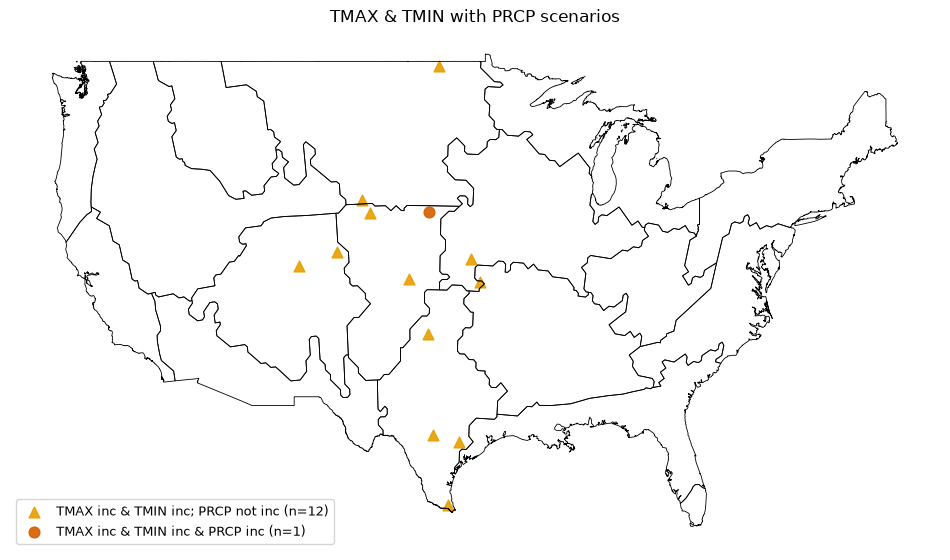

In [10]:
fig, ax, gdfs, merged = plot_three_variable_scenarios_on_shapefile(
    df_stations=df_neon,
    df_trends=df_trend_recent,
    shp_path=shp_path,
    var_tmax="TMAX",
    var_tmin="TMIN",
    var_prcp="PRCP",
    save_dir=str(base_dir / "Figures_trend") + "/",
    title="TMAX & TMIN with PRCP scenarios",
    filename="TMAX_TMIN_PRCP_scenarios.jpeg",
)


In [11]:


def plot_spei_consistency_on_shapefile(
    df_stations: pd.DataFrame,
    df_spei: pd.DataFrame,
    shp_path: str,
    spei_vars: list[str] | None = None,          # default uses all df_spei[variable].unique()
    station_id_col: str = "ID",
    lat_col: str = "Lat",
    lon_col: str = "Lon",
    variable_col: str = "variable",
    trend_col: str = "trend",
    increasing_label: str = "increasing",
    decreasing_label: str = "decreasing",
    station_crs: str = "EPSG:4326",
    figsize: tuple = (12, 8),
    boundary_color: str = "black",
    boundary_lw: float = 0.6,
    point_size: float = 60,
    alpha: float = 0.9,
    title: str | None = None,
    colors: dict | None = None,
    save_dir: str | None = None,
    filename: str | None = None,
    dpi: int = 300,
):
    """
    SPEI multi-timescale classification per station:

    - all_dec: all spei_vars are 'decreasing' -> red downward triangle
    - all_inc: all spei_vars are 'increasing' -> green upward triangle
    - any_dec: at least one is 'decreasing' but not all decreasing -> orange downward triangle

    Stations not matching these are not plotted.
    """

    # ---- checks ----
    for col in [station_id_col, lat_col, lon_col]:
        if col not in df_stations.columns:
            raise ValueError(f"df_stations missing column: {col}")
    for col in [station_id_col, variable_col, trend_col]:
        if col not in df_spei.columns:
            raise ValueError(f"df_spei missing column: {col}")

    # ---- default vars ----
    if spei_vars is None:
        spei_vars = list(pd.Series(df_spei[variable_col].unique()).dropna().astype(str))
        spei_vars = sorted(spei_vars)

    # ---- default colors ----
    default_colors = {
        "all_dec": "red",
        "all_inc": "green",
        "any_dec": "#F4A261",  # nice orange shade
    }
    if colors:
        default_colors.update(colors)

    # ---- shapefile ----
    gdf_shape = gpd.read_file(shp_path)
    if gdf_shape.crs is None:
        raise ValueError("Shapefile has no CRS defined. Define it in GIS or set it in code.")

    # ---- prep trends ----
    t = df_spei[[station_id_col, variable_col, trend_col]].copy()
    t[variable_col] = t[variable_col].astype(str).str.strip()
    t[trend_col] = t[trend_col].astype(str).str.strip().str.lower()

    inc = increasing_label.lower()
    dec = decreasing_label.lower()

    # keep only the requested spei variables
    t = t[t[variable_col].isin(spei_vars)].copy()

    # if duplicates per (ID, variable) exist, keep first
    t = t.drop_duplicates(subset=[station_id_col, variable_col], keep="first")

    # pivot to wide: rows=ID, cols=variable, values=trend
    wide = t.pivot(index=station_id_col, columns=variable_col, values=trend_col)

    # require that a station has all requested spei variables present
    wide = wide.dropna(subset=spei_vars, how="any")

    # ---- classify per station ----
    all_dec_mask = (wide[spei_vars] == dec).all(axis=1)
    all_inc_mask = (wide[spei_vars] == inc).all(axis=1)
    any_dec_mask = (wide[spei_vars] == dec).any(axis=1) & (~all_dec_mask)  # at least one dec, but not all dec

    class_series = pd.Series(index=wide.index, dtype="object")
    class_series.loc[all_dec_mask] = "all_dec"
    class_series.loc[all_inc_mask] = "all_inc"
    class_series.loc[any_dec_mask] = "any_dec"

    class_series = class_series.dropna()

    # ---- merge with station coords ----
    s = df_stations[[station_id_col, lat_col, lon_col]].copy()
    m = s.merge(class_series.rename("spei_class"), left_on=station_id_col, right_index=True, how="inner")

    # ---- to GeoDataFrame ----
    gdf = gpd.GeoDataFrame(
        m,
        geometry=gpd.points_from_xy(m[lon_col], m[lat_col]),
        crs=station_crs,
    ).to_crs(gdf_shape.crs)

    gdf_all_dec = gdf[gdf["spei_class"] == "all_dec"].copy()
    gdf_all_inc = gdf[gdf["spei_class"] == "all_inc"].copy()
    gdf_any_dec = gdf[gdf["spei_class"] == "any_dec"].copy()

    # ---- plot ----
    fig, ax = plt.subplots(figsize=figsize)
    gdf_shape.boundary.plot(ax=ax, color=boundary_color, linewidth=boundary_lw)

    if not gdf_all_inc.empty:
        gdf_all_inc.plot(
            ax=ax, marker="^", color=default_colors["all_inc"],
            markersize=point_size, alpha=alpha,
            label=f"All SPEI increasing (n={len(gdf_all_inc)})",
        )

    if not gdf_all_dec.empty:
        gdf_all_dec.plot(
            ax=ax, marker="v", color=default_colors["all_dec"],
            markersize=point_size, alpha=alpha,
            label=f"All SPEI decreasing (n={len(gdf_all_dec)})",
        )

    if not gdf_any_dec.empty:
        gdf_any_dec.plot(
            ax=ax, marker="v", color=default_colors["any_dec"],
            markersize=point_size, alpha=alpha,
            label=f"At least one SPEI decreasing (n={len(gdf_any_dec)})",
        )

    ax.set_axis_off()

    if title is None:
        title = f"SPEI consistency ({', '.join(spei_vars)})"
    ax.set_title(title)
    ax.legend(loc="lower left", frameon=True, fontsize=9)

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        if filename is None:
            filename = f"SPEI_consistency_{'_'.join(spei_vars)}.jpeg"
        outpath = os.path.join(save_dir, filename)
        plt.savefig(outpath, dpi=dpi, bbox_inches="tight")

    return fig, ax, {"all_inc": gdf_all_inc, "all_dec": gdf_all_dec, "any_dec": gdf_any_dec}, wide


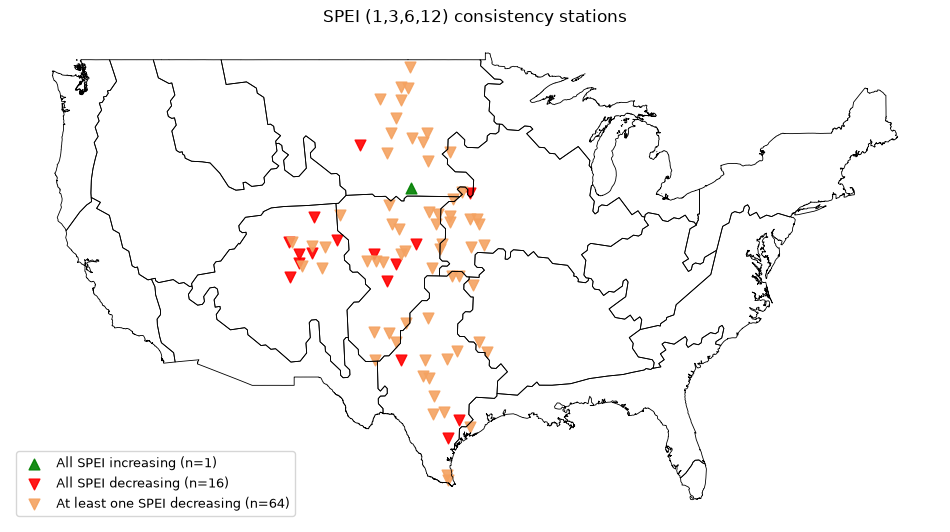

In [12]:
fig, ax, gdfs, wide = plot_spei_consistency_on_shapefile(
    df_stations=df_neon,
    df_spei=df_spei_recent,
    shp_path=shp_path,
    spei_vars=["spei1", "spei3", "spei6", "spei12"],
    save_dir=str(base_dir / "Figures_trend") + "/",
    filename="SPEI_consistency_recent.jpeg",
    title="SPEI (1,3,6,12) consistency stations",
)
